# Parity Si 1D

**Purpose.** Reproduce the named radiative-transfer experiment with its original computational workflow.

**Distinction.** This notebook is the canonical study; existing code, parameters, outputs, and execution order are unchanged.


# 1D parity discrete ordinates

Traditional sparse solver for the odd-even formulation. The model coefficients, source, and inflow data come from `src/configuration/rte_1d_settings.py`. Only the non-negative velocity half-domain is discretised; negative velocities are reconstructed from the parity variables.

In [1]:
from io import BytesIO
from pathlib import Path
from IPython.display import Image, display
import os
import site
import sys

# Use the system NumPy/Matplotlib pair. The user-site versions are ABI-incompatible
# with the system mpl_toolkits.mplot3d package used by this Jupyter kernel.
USER_SITE = site.getusersitepackages()
sys.path[:] = [path for path in sys.path if path != USER_SITE]
os.environ["PYTHONNOUSERSITE"] = "1"
os.environ["MPLBACKEND"] = "Agg"

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# The settings module only needs jax.numpy array helpers. Keep plotting on the
# compatible system NumPy/Matplotlib pair and provide those helpers via NumPy.
import types
jax_compat = types.ModuleType("jax")
jax_compat.numpy = np
sys.modules["jax"] = jax_compat
sys.modules["jax.numpy"] = np
if USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)  # Needed for ml_collections in the settings file.

def display_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    display(Image(data=buffer.getvalue()))

SRC_ROOT = Path('/home/sheny-y23/rte_oe/src')
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from configuration.rte_1d_settings import get_config
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsmr
from scipy.special import roots_legendre
from scipy.linalg import solve_banded
from time import perf_counter

/tmp/ipykernel_3244514/3686648384.py:39: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 1.21.5)
  from scipy.sparse import coo_matrix


## Odd-even sparse solver

This cell contains the complete traditional solver. It uses positive Gauss-Legendre ordinates and solves for $j(x,v)$ and $r(x,v)$ simultaneously.

In [2]:
def derivative_terms(i, n, h):
    if n < 2:
        raise ValueError('At least two spatial cells are required.')
    if i == 0:
        return ((0, -1.0 / h), (1, 1.0 / h))
    if i == n - 1:
        return ((n - 2, -1.0 / h), (n - 1, 1.0 / h))
    return ((i - 1, -0.5 / h), (i + 1, 0.5 / h))


def _deprecated_collocated_lsmr_solver(config, num_angles=None, atol=1e-10, btol=1e-10, maxiter=None, progress=True, max_estimated_nnz=10_000_000):
    started = perf_counter()
    nx = int(config.model.grid_sizes[0])
    # grid_sizes[1] is the full symmetric velocity grid; parity stores v in [0, 1] only.
    nv = int(num_angles if num_angles is not None else config.model.grid_sizes[1] // 2)
    # The (I-Pi) term couples all positive velocities at every x node.
    estimated_nnz = nx * (3 * nv + nv * (3 * nv + 3) + 3 * nv) + 4 * nv
    if estimated_nnz > max_estimated_nnz:
        raise ValueError(
            f'Estimated matrix size is {estimated_nnz:,} nonzeros for Nx={nx}, Nv+={nv}; '
            'this explicit sparse assembly is unsafe. Reduce run_grid_sizes, or use a matrix-free parity operator.'
        )
    xmin, xmax = map(float, config.mesh['domain']['x'])
    dx = (xmax - xmin) / nx
    x = xmin + (np.arange(nx) + 0.5) * dx
    v, w = roots_legendre(nv)
    v, w = 0.5 * (v + 1.0), 0.5 * w
    eps = float(config.model.knudsen_number)
    if eps <= 0.0:
        raise ValueError('knudsen_number must be positive.')
    sigma_s = np.broadcast_to(np.asarray(config.model.coeff['scattering'](x), dtype=float), (nx,))
    sigma_a = np.broadcast_to(np.asarray(config.model.coeff['absorption'](x), dtype=float), (nx,))
    coeff = sigma_s + eps**2 * sigma_a
    X, V = np.meshgrid(x, v, indexing='ij')
    q_plus = np.broadcast_to(np.asarray(config.model.source(X, V), dtype=float), (nx, nv))
    q_minus = np.broadcast_to(np.asarray(config.model.source(X, -V), dtype=float), (nx, nv))
    q_even, q_odd = 0.5 * (q_plus + q_minus), 0.5 * (q_plus - q_minus)
    n = nx * nv
    rows, cols, data, rhs = [], [], [], []
    dof = lambda kind, ix, iv: kind * n + ix * nv + iv
    def add(entries, value):
        row = len(rhs)
        for col, val in entries:
            rows.append(row); cols.append(col); data.append(val)
        rhs.append(value)
    for ix in range(nx):
        deriv = derivative_terms(ix, nx, dx)
        entries = []
        for iv in range(nv):
            entries += [(dof(0, neighbour, iv), w[iv] * v[iv] * d) for neighbour, d in deriv]
            entries.append((dof(1, ix, iv), sigma_a[ix] * w[iv]))
        add(entries, np.dot(w, q_even[ix]))
        for iv in range(nv):
            entries = []
            for neighbour, d in deriv:
                entries.append((dof(0, neighbour, iv), eps**2 * v[iv] * d))
                entries += [(dof(0, neighbour, iw), -eps**2 * w[iw] * v[iw] * d) for iw in range(nv)]
            entries.append((dof(1, ix, iv), coeff[ix]))
            entries += [(dof(1, ix, iw), -coeff[ix] * w[iw]) for iw in range(nv)]
            add(entries, eps**2 * (q_even[ix, iv] - np.dot(w, q_even[ix])))
            entries = [(dof(0, ix, iv), coeff[ix])]
            entries += [(dof(1, neighbour, iv), v[iv] * d) for neighbour, d in deriv]
            add(entries, eps * q_odd[ix, iv])
    for iv in range(nv):
        add([(dof(1, 0, iv), 1.0), (dof(0, 0, iv), eps)], float(config.model.bdy_cond['f_l'](v[iv])))
        add([(dof(1, nx - 1, iv), 1.0), (dof(0, nx - 1, iv), -eps)], float(config.model.bdy_cond['f_r'](-v[iv])))
    A = coo_matrix((data, (rows, cols)), shape=(len(rhs), 2 * n)).tocsr()
    rhs = np.asarray(rhs)
    # Keep one continuous Krylov process. Restarting every 10 steps destroys
    # the LSMR search space and can make the residual stagnate. show=True
    # prints LSMR's residual monitor at regular iterations.
    out = lsmr(A, rhs, atol=atol, btol=btol, maxiter=maxiter, show=progress)
    u, total_iterations = out[0], out[2]
    j, r = u[:n].reshape(nx, nv), u[n:].reshape(nx, nv)
    return dict(x=x, velocity=v, weights=w, j=j, r=r, rho=r @ w,
                f_positive=r + eps * j, f_negative=r - eps * j,
                iterations=total_iterations, istop=out[1], residual_norm=out[3], runtime_seconds=perf_counter() - started)

## SI-style odd-even iteration

This is the active solver. It uses the same face-based diamond-difference source iteration as `source_iteration_1d.ipynb`, while storing only the non-negative velocity pairs and reconstructing $r,j$ after each sweep.

In [3]:
def _field_1d(fn, values, shape):
    return np.broadcast_to(np.asarray(fn(values), dtype=float), shape)


def solve_parity_si_1d(config, tol=1e-10, max_iter=2**14, report_every=100, num_positive=None, use_dsa=True, dsa_relaxation=1.0e-2):
    """SI diamond-difference sweep with diffusion synthetic acceleration."""
    started = perf_counter()
    nx, full_nv = map(int, config.model.grid_sizes[:2])
    if full_nv % 2:
        raise ValueError('grid_sizes[1] must be even for paired velocities.')
    npos = int(num_positive or full_nv // 2)
    xmin, xmax = map(float, config.mesh['domain']['x'])
    dx = (xmax - xmin) / nx
    x_faces = np.linspace(xmin, xmax, nx + 1)
    x = 0.5 * (x_faces[:-1] + x_faces[1:])
    # Match source_iteration_1d.ipynb's uniform full-velocity trapezoidal rule.
    full_v = np.linspace(-1.0, 1.0, 2 * npos)
    dv = full_v[1] - full_v[0]
    full_w = np.full(2 * npos, dv); full_w[[0, -1]] *= 0.5
    v, w = full_v[full_v > 0], full_w[full_v > 0]
    eps = float(config.model.knudsen_number)
    sigma_s = _field_1d(config.model.coeff['scattering'], x, (nx,))
    sigma_a = _field_1d(config.model.coeff['absorption'], x, (nx,))
    sigma_t = sigma_s + eps**2 * sigma_a
    if np.any(sigma_s <= 0.0):
        raise ValueError('DSA requires strictly positive scattering coefficients.')
    diffusion = 1.0 / (3.0 * sigma_s)
    sigma_a_face = _field_1d(config.model.coeff['absorption'], x_faces, (nx + 1,))
    X, V = np.meshgrid(x, v, indexing='ij')
    source_p = np.broadcast_to(np.asarray(config.model.source(X, V), float), (nx, npos))
    source_m = np.broadcast_to(np.asarray(config.model.source(X, -V), float), (nx, npos))
    # f_plus is f(v), f_minus is f(-v), both defined on spatial faces.
    f_plus = np.ones((nx + 1, npos)); f_minus = np.ones((nx + 1, npos))
    f_plus[0] = np.broadcast_to(np.asarray(config.model.bdy_cond['f_l'](v), float), (npos,))
    f_minus[-1] = np.broadcast_to(np.asarray(config.model.bdy_cond['f_r'](-v), float), (npos,))
    def collision_source(fp, fm):
        r_cell = 0.25 * (fp[1:] + fp[:-1] + fm[1:] + fm[:-1])
        rho = r_cell @ w
        return sigma_s[:, None] * rho[:, None] + eps**2 * source_p, sigma_s[:, None] * rho[:, None] + eps**2 * source_m
    def rho_on_faces(fp, fm):
        return 0.5 * (fp + fm) @ w
    def dsa_correction(rho_before, rho_after):
        delta = np.zeros(nx + 1)
        if not use_dsa or nx < 2:
            return delta
        interior = nx - 1
        diagonal = diffusion[:-1] + diffusion[1:] + sigma_a_face[1:-1] * dx**2
        bands = np.zeros((3, interior))
        bands[1] = diagonal
        if interior > 1:
            off_diagonal = -diffusion[1:-1]
            bands[0, 1:] = off_diagonal
            bands[2, :-1] = off_diagonal
        rhs = (rho_after[1:-1] - rho_before[1:-1]) * (dx / eps)**2
        delta[1:-1] = solve_banded((1, 1), bands, rhs)
        return delta
    converged = False
    for iteration in range(1, max_iter + 1):
        previous_plus, previous_minus = f_plus.copy(), f_minus.copy()
        rho_before = rho_on_faces(previous_plus, previous_minus)
        _, q_minus = collision_source(f_plus, f_minus)
        for i in range(nx - 1, -1, -1):
            denom = 0.5 * sigma_t[i] + eps * v / dx
            f_minus[i] = q_minus[i] / denom - (0.5 * sigma_t[i] - eps * v / dx) / denom * f_minus[i + 1]
        q_plus, _ = collision_source(f_plus, f_minus)
        for i in range(nx):
            denom = 0.5 * sigma_t[i] + eps * v / dx
            f_plus[i + 1] = q_plus[i] / denom - (0.5 * sigma_t[i] - eps * v / dx) / denom * f_plus[i]
        correction = dsa_relaxation * dsa_correction(rho_before, rho_on_faces(f_plus, f_minus))
        f_plus += correction[:, None]
        f_minus += correction[:, None]
        diff = np.hypot(np.linalg.norm(f_plus - previous_plus), np.linalg.norm(f_minus - previous_minus))
        if iteration % report_every == 0 or iteration == 1:
            print(f'Iteration {iteration:6d}: diff = {diff:.6e}')
        if diff < tol:
            converged = True
            break
    f_positive = 0.5 * (f_plus[1:] + f_plus[:-1])
    f_negative = 0.5 * (f_minus[1:] + f_minus[:-1])
    r = 0.5 * (f_positive + f_negative)
    j = (f_positive - f_negative) / (2.0 * eps)
    return dict(x=x, x_faces=x_faces, velocity=v, weights=w, r=r, j=j, rho=r @ w,
                f_positive=f_positive, f_negative=f_negative, iterations=iteration,
                final_difference=diff, converged=converged, runtime_seconds=perf_counter() - started)

In [4]:
config = get_config()

# Coefficients, source, and inflow always come from rte_1d_settings.py.
# The full configured (1024, 2048) grid would create about 3.2 billion matrix entries
# in this explicitly assembled parity solver and will exhaust notebook memory.
# Use None only with a matrix-free implementation.
run_grid_sizes = (512,512)
# None uses half of the configured full velocity grid.
num_positive = None
dsa_relaxation = 1.0e-2
if run_grid_sizes is not None:
    config.model.grid_sizes = run_grid_sizes

print('epsilon:', config.model.knudsen_number)
print('grid_sizes:', config.model.grid_sizes)
print('non-negative-half-domain ordinates:', num_positive or config.model.grid_sizes[1] // 2)
print('DSA relaxation:', dsa_relaxation)

epsilon: 0.001
grid_sizes: (512, 512)
non-negative-half-domain ordinates: 256
DSA relaxation: 0.01


In [5]:
result = solve_parity_si_1d(config, num_positive=num_positive, tol=1e-12, report_every=100, dsa_relaxation=dsa_relaxation)
print(f"SI iterations: {result['iterations']}")
print(f"converged: {result['converged']}")
print(f"final difference: {result['final_difference']:.6e}")
if not result['converged']:
    print('WARNING: max_iter was reached; the following error is dominated by iteration error, not grid error.')
print(f"when knudsen number is {config.model.knudsen_number}, runtime: {result['runtime_seconds']:.3f} s")

Iteration      1: diff = 1.979513e+02
Iteration    100: diff = 5.222643e-02
Iteration    200: diff = 6.968054e-03
Iteration    300: diff = 8.987743e-04
Iteration    400: diff = 1.051509e-04
Iteration    500: diff = 1.062037e-05
Iteration    600: diff = 9.736164e-07
Iteration    700: diff = 1.647549e-07
Iteration    800: diff = 3.847814e-08
Iteration    900: diff = 7.627218e-09
Iteration   1000: diff = 1.301277e-09
Iteration   1100: diff = 1.964771e-10
Iteration   1200: diff = 2.596402e-11
Iteration   1300: diff = 3.449705e-12
SI iterations: 1339
converged: True
final difference: 8.512458e-13
when knudsen number is 0.001, runtime: 26.741 s


In [6]:
# Exact solution f(x, v) = 1 - x; it is independent of velocity.
# f_exact = 1.0 - result['x'][:, None]
# rho_exact = 1.0 - result['x']
# w = result['weights'][None, :]
# f_error_sq = np.sum(w * (result['f_positive'] - f_exact)**2) + np.sum(w * (result['f_negative'] - f_exact)**2)
# f_exact_sq = 2.0 * np.sum(w * f_exact**2)
# rel_l2_f = np.sqrt(f_error_sq / f_exact_sq)
# rel_l2_rho = np.linalg.norm(result['rho'] - rho_exact) / np.linalg.norm(rho_exact)
# print(f'Relative L2 error of f: {rel_l2_f:.6e}')
# print(f'Relative L2 error of rho: {rel_l2_rho:.6e}')
# print(f'End-to-end cost: {result["runtime_seconds"]:.3f} s')
# if not result['converged']:
#     print('Do not use this point in a mesh-convergence table. Increase max_iter or use DSA/AP acceleration first.')

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(result['x'], result['rho'], label=r'$\rho$')
axes[0].set(xlabel='x', ylabel='density', title='Macroscopic density')
axes[0].grid()
axes[0].legend()

for index in (0, len(result['velocity']) // 2, -1):
    axes[1].plot(result['x'], result['f_positive'][:, index],
                 label=fr"$f(v={result['velocity'][index]:.2f})$")
axes[1].set(xlabel='x', ylabel='f', title='Positive-direction distribution')
axes[1].grid()
axes[1].legend()
plt.tight_layout()

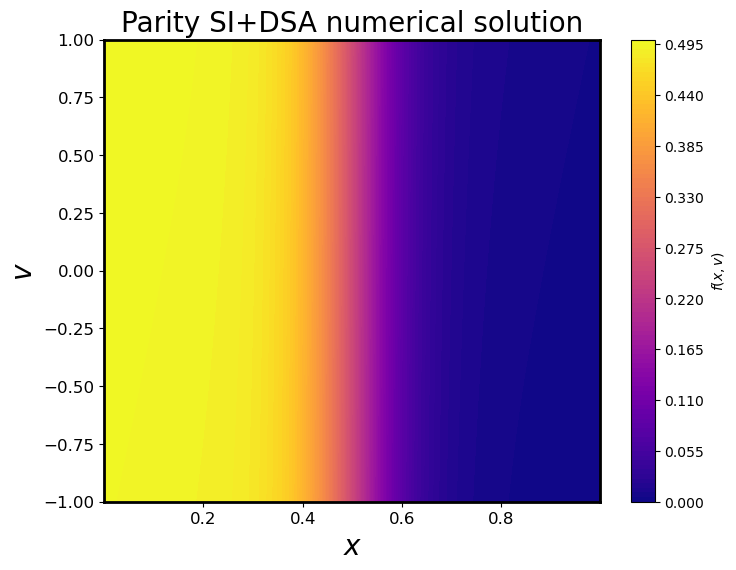

In [8]:
# Reconstruct the full velocity domain from the parity variables.
v_plot = np.concatenate((-result["velocity"][::-1], result["velocity"]))
f_plot = np.concatenate(
    (result["f_negative"][:, ::-1], result["f_positive"]),
    axis=1,
)
X_plot, V_plot = np.meshgrid(result["x"], v_plot, indexing="ij")

font_format = {"size": 20}
plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
contour = plt.contourf(X_plot, V_plot, f_plot, 100, cmap="plasma")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(contour, label=r"$f(x,v)$")
plt.title("Parity SI+DSA numerical solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
display_figure(plt.gcf())
plt.close()

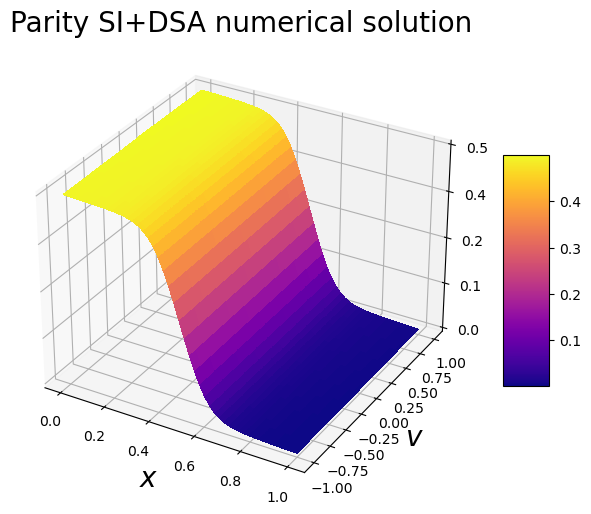

In [9]:
from matplotlib.ticker import LinearLocator

font_format = {"size": 20}
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(
    X_plot, V_plot, f_plot, cmap="plasma", linewidth=0, antialiased=False
)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$v$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Parity SI+DSA numerical solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)

display_figure(fig)
plt.close(fig)